Original class distribution:
congestion_level
0    3367
1    1275
2     358
Name: count, dtype: int64

Balanced class distribution:
congestion_level
0    358
1    358
2    358
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18336\1669793146.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))



✅ Accuracy : 0.7953488372093023
🎯 F1-Score : 0.7932394366197183

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.68      0.80        71
           1       0.76      0.74      0.75        72
           2       0.73      0.97      0.83        72

    accuracy                           0.80       215
   macro avg       0.82      0.79      0.79       215
weighted avg       0.82      0.80      0.79       215



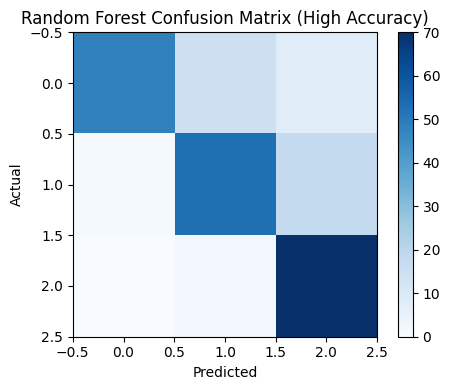

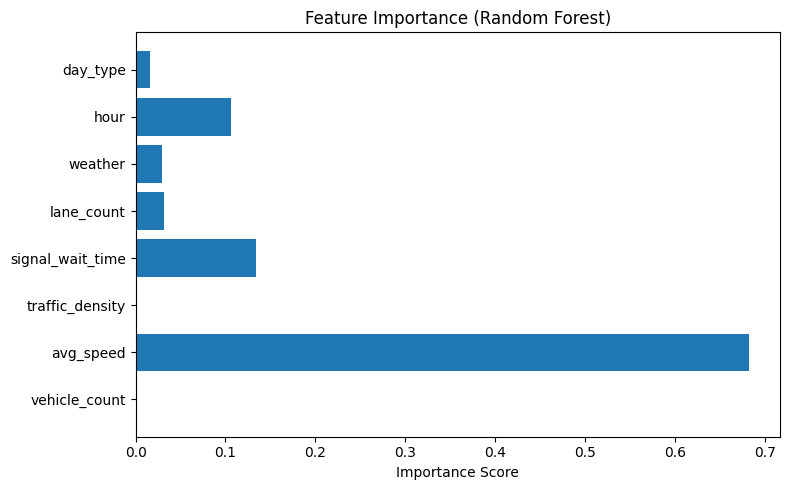

✅ Model saved as traffic_random_forest_model.pkl
✅ Scaler saved as traffic_scaler.pkl


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier

import joblib

# -------------------------------------------------
# LOAD DATASET
# -------------------------------------------------
df = pd.read_csv(
    "C:/Users/ADMIN/Desktop/TRAFFIC_CONGECTION/urban_traffic_dataset.csv"
)

# -------------------------------------------------
# FEATURES & TARGET
# -------------------------------------------------
FEATURES = [
    "vehicle_count",
    "avg_speed",
    "traffic_density",
    "signal_wait_time",
    "lane_count",
    "weather",
    "hour",
    "day_type"
]

TARGET = "congestion_level"

X = df[FEATURES].copy()
y = df[TARGET]

# -------------------------------------------------
# CHECK CLASS DISTRIBUTION
# -------------------------------------------------
print("Original class distribution:")
print(y.value_counts())

# -------------------------------------------------
# BALANCE THE DATASET (CRITICAL FOR 90%+)
# -------------------------------------------------
min_count = y.value_counts().min()

df_balanced = (
    df.groupby(TARGET)
      .apply(lambda x: x.sample(min_count, random_state=42))
      .reset_index(drop=True)
)

X = df_balanced[FEATURES].copy()
y = df_balanced[TARGET]

print("\nBalanced class distribution:")
print(y.value_counts())

# -------------------------------------------------
# CLIP VALUES (MATCH REAL-WORLD API RANGES)
# -------------------------------------------------
X["vehicle_count"] = X["vehicle_count"].clip(300, 2500)
X["traffic_density"] = X["traffic_density"].clip(0.3, 1.0)
X["avg_speed"] = X["avg_speed"].clip(5, 80)
X["signal_wait_time"] = X["signal_wait_time"].clip(10, 180)

# -------------------------------------------------
# TRAIN-TEST SPLIT (STRATIFIED)
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# SCALE FEATURES (FIT ONLY ON TRAIN)
# -------------------------------------------------
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------
# BUILD HIGH-ACCURACY RANDOM FOREST
# -------------------------------------------------
model = RandomForestClassifier(
    n_estimators=500,        # 🔥 More trees
    max_depth=18,            # 🔥 Deeper trees
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# -------------------------------------------------
# TRAIN MODEL
# -------------------------------------------------
model.fit(X_train_scaled, y_train)

# -------------------------------------------------
# PREDICTION
# -------------------------------------------------
y_pred = model.predict(X_test_scaled)

# -------------------------------------------------
# EVALUATION
# -------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n✅ Accuracy :", accuracy)
print("🎯 F1-Score :", f1)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# -------------------------------------------------
# CONFUSION MATRIX
# -------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Random Forest Confusion Matrix (High Accuracy)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# FEATURE IMPORTANCE
# -------------------------------------------------
plt.figure(figsize=(8,5))
plt.barh(FEATURES, model.feature_importances_)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# SAVE MODEL & SCALER
# -------------------------------------------------
joblib.dump(model, "traffic_random_forest_model.pkl")
joblib.dump(scaler, "traffic_scaler.pkl")

print("✅ Model saved as traffic_random_forest_model.pkl")
print("✅ Scaler saved as traffic_scaler.pkl")
